(200, 5)
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


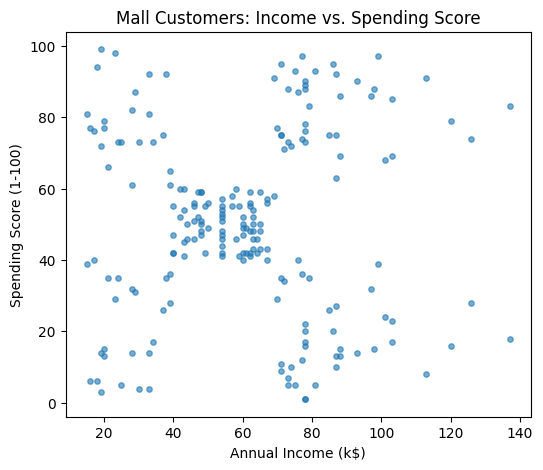

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
DATA_PATH = "/kaggle/input/datasets/taibakhan1318/customer/Mall_Customers.csv"
df = pd.read_csv(DATA_PATH)

# Display dataset shape and first 5 rows
print(df.shape)
print(df.head())

# Create scatter plot
plt.figure(figsize=(6, 5))

plt.scatter(
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"],
    s=15,
    alpha=0.6
)

# Add labels and title
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Mall Customers: Income vs. Spending Score")

# Display the plot
plt.show()

In [4]:
from sklearn.preprocessing import StandardScaler

# Select features
X = df[["Annual Income (k$)", "Spending Score (1-100)"]].values

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Display the first 5 scaled rows
print(X_scaled[:5])

[[-1.73899919 -0.43480148]
 [-1.73899919  1.19570407]
 [-1.70082976 -1.71591298]
 [-1.70082976  1.04041783]
 [-1.66266033 -0.39597992]]


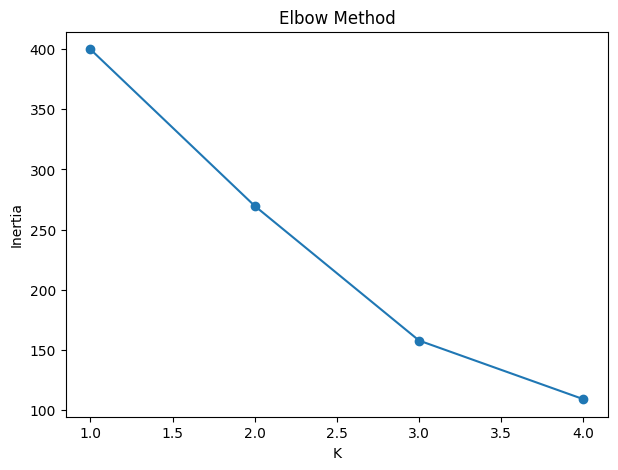

In [10]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Calculate inertia for K values from 1 to 10
inertias = []

for k in range(1, 5):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

# Plot the Elbow Method
plt.figure(figsize=(7, 5))
plt.plot(range(1, 5), inertias, marker="o")

plt.xlabel("K")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()


In [13]:
from sklearn.cluster import KMeans

# Create and fit the K-Means model
kmeans = KMeans(n_clusters=13, random_state=42, n_init=10)
kmeans.fit(X_scaled)

# Assign each customer to a cluster
df["Cluster"] = kmeans.predict(X_scaled)

# Display the number of customers in each cluster
print(df["Cluster"].value_counts())


Cluster
0     34
6     30
12    21
2     18
1     15
10    14
5     13
3     13
4     12
7     11
11     8
8      7
9      4
Name: count, dtype: int64


In [24]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

# Silhouette Score for K=5
score_5 = silhouette_score(X_scaled, df["Cluster"])
print(f"Silhouette Score (K=5): {score_5:.3f}")

# K=3
km3 = KMeans(n_clusters=4, random_state=42, n_init=10).fit(X_scaled)
score_3 = silhouette_score(X_scaled, km3.labels_)
print(f"Silhouette Score (K=3): {score_3:.3f}")

# K=7
km7 = KMeans(n_clusters=5, random_state=42, n_init=10).fit(X_scaled)
score_7 = silhouette_score(X_scaled, km7.labels_)
print(f"Silhouette Score (K=7): {score_7:.3f}")

# Compare all three scores
print("\nSilhouette Score Comparison:")
print(f"K=3: {score_3:.3f}")
print(f"K=5: {score_5:.3f}")
print(f"K=7: {score_7:.3f}")

Silhouette Score (K=5): 0.411
Silhouette Score (K=3): 0.494
Silhouette Score (K=7): 0.555

Silhouette Score Comparison:
K=3: 0.494
K=5: 0.411
K=7: 0.555
